# Breakout & Fakeout Dataset Exploration

### Overview & Objective
This notebook is dedicated to **loading, inspecting, and auditing the unified breakout dataset** (`data/unified_breakout_dataset.csv`) generated across 10 large-cap US equities.

**Exploration Stages:**
1. **Environment Setup & Data Ingestion**: Load the unified CSV dataset and inspect column data types.
2. **Dataset Structure & Quality Audit**: Verify row counts, column types, and missing value checks.
3. **Statistical Summary**: Comprehensive descriptive statistics across all numerical features.
4. **Target Label & Stock Breakdown**: Distribution of `breakout`, `fakeout`, and `neutral/retest` across the 10 assets.
5. **Forward-Looking Performance Analysis**: Comparing 5-day confirmation and 30-day continuation behavior by class.
6. **Exploratory Visualizations**: Visualizing class balance, return distributions, and breakout characteristics.


## 1. Environment Setup & Data Ingestion
Import analytical and visualization libraries, configure aesthetic themes, and load the unified dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

# Load unified dataset
df = pd.read_csv("data/unified_breakout_dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])

print(f"Dataset Successfully Loaded!")
print(f"Total Breakout Events: {df.shape[0]:,} rows")
print(f"Total Features / Columns: {df.shape[1]} columns")
print(f"Date Coverage: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")


Dataset Successfully Loaded!
Total Breakout Events: 871 rows
Total Features / Columns: 30 columns
Date Coverage: 2000-02-18 to 2026-06-26


## 2. Dataset Preview & Column Inspection
Preview the first 10 rows of the dataset to inspect feature values, dates, tickers, and labels.


In [2]:
df.head(10)


,Ticker,Date,Resistance_Distance_%,Close_Position,Daily_Range_%,Range_Ratio,Volume_Ratio,Volume_Surge_10,Momentum_5d_%,Momentum_10d_%,Momentum_20d_%,MA_Ratio,Distance_MA10_%,Distance_MA30_%,ATR_Pct,Volatility_10d,Price_Range_10d_%,Resistance_Tests_30d,RSI_14,Close,Resistance,Label,Days_Above_5d,Avg_Close_5d,Return_5d_%,Return_30d_%,Max_Gain_30d_%,Max_Drawdown_30d_%,Pct_Days_Above_30d,Continued_Up_30d
0,AAPL,2000-03-01,7.25,0.871,10.41,1.93,2.40,2.99,12.10,9.51,29.99,1.035,14.03,18.03,5.30,0.0281,10.17,3,65.81,0.9744,0.9085,breakout,5,0.9280,-6.38,-16.16,15.40,-19.52,83.3,False
1,AAPL,2000-03-21,2.18,0.880,11.21,2.07,1.47,1.67,18.11,9.82,18.56,1.028,11.13,14.27,5.43,0.0324,10.33,1,53.84,1.0090,0.9875,breakout,5,1.0511,3.10,-14.73,11.44,-22.28,26.7,False
2,AAPL,2000-03-22,5.44,0.985,8.89,1.47,1.58,1.68,24.03,18.19,24.03,1.032,17.58,21.39,5.24,0.0439,15.78,1,68.13,1.0781,1.0225,breakout,4,1.0388,-5.72,-23.23,4.29,-27.26,13.3,False
3,AAPL,2000-08-31,1.56,0.781,4.21,0.97,1.70,1.57,8.60,18.47,26.95,1.075,11.28,19.65,3.71,0.0246,19.18,3,86.55,0.9113,0.8973,neutral/retest,3,0.9128,-3.38,-63.79,5.23,-68.62,16.7,False
4,AAPL,2001-01-18,1.01,0.944,6.02,0.74,2.49,2.08,12.83,14.12,31.14,1.089,10.41,20.19,6.95,0.0522,21.74,3,71.83,0.2795,0.2767,breakout,5,0.2982,6.69,3.01,20.40,-8.03,93.3,True
5,AAPL,2001-01-19,4.00,0.929,4.49,0.61,1.49,1.23,8.33,14.29,39.29,1.099,13.66,24.88,6.75,0.0543,14.42,3,74.19,0.2916,0.2804,breakout,5,0.2983,0.32,4.49,15.38,-11.86,93.3,True
6,AAPL,2001-01-23,4.46,0.767,9.15,1.38,1.76,1.37,19.71,23.77,45.78,1.115,15.90,29.24,7.08,0.0519,17.99,2,75.28,0.3066,0.2935,breakout,4,0.3094,6.10,3.66,9.76,-16.16,53.3,True
7,AAPL,2001-01-29,3.58,0.971,10.09,1.73,1.61,1.28,12.66,26.18,46.41,1.143,14.71,31.06,6.12,0.0487,20.46,3,73.03,0.3243,0.3131,neutral/retest,3,0.3150,-6.92,-9.80,3.75,-20.75,20.0,False
8,AAPL,2001-04-19,6.81,0.986,8.36,0.99,3.85,3.84,17.98,31.90,27.80,1.010,21.10,22.30,7.45,0.0567,20.72,2,61.05,0.3846,0.3601,breakout,4,0.3671,-4.00,-18.78,5.44,-24.96,43.3,False
9,AAPL,2001-11-26,5.79,0.892,7.81,1.99,1.62,2.20,12.65,14.22,14.46,1.035,10.21,14.06,4.24,0.0240,10.48,8,68.31,0.3196,0.3021,breakout,5,0.3120,-1.50,1.31,12.45,-5.99,100.0,True


## 3. Data Types & Integrity Check
Verify that all columns have appropriate data types and confirm that there are zero missing or null values across the 871 rows.


In [3]:
info_df = pd.DataFrame({
    "Data_Type": df.dtypes,
    "Non_Null_Count": df.notnull().sum(),
    "Null_Count": df.isnull().sum(),
    "Null_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})
info_df


,Data_Type,Non_Null_Count,Null_Count,Null_Percentage
Ticker,str,871,0,0.0
Date,datetime64[us],871,0,0.0
Resistance_Distance_%,float64,871,0,0.0
Close_Position,float64,871,0,0.0
Daily_Range_%,float64,871,0,0.0
Range_Ratio,float64,871,0,0.0
Volume_Ratio,float64,871,0,0.0
Volume_Surge_10,float64,871,0,0.0
Momentum_5d_%,float64,871,0,0.0
Momentum_10d_%,float64,871,0,0.0


## 4. Descriptive Statistics
Statistical summary (mean, std, min, 25%, median, 75%, max) for all quantitative features and continuation metrics.


In [4]:
df.describe().round(2)


,Date,Close,Resistance,Breakout_Pct,Close_Position,Volume_Ratio,Days_Above_5d,Avg_Close_5d,Return_5d_%,Return_30d_%,Max_Gain_30d_%,Max_Drawdown_30d_%,Pct_Days_Above_30d
count,871,871.00,871.00,871.00,871.00,871.00,871.00,871.00,871.00,871.00,871.00,871.00,871.00
mean,2014-01-04 15:44:01.102181,67.86,65.94,3.10,0.88,1.96,4.10,68.20,0.71,3.93,12.60,-8.13,72.28
min,2000-02-18 00:00:00,0.09,0.09,1.00,0.70,1.20,0.00,0.11,-33.74,-63.79,-7.35,-68.62,0.00
25%,2007-04-22 00:00:00,6.08,5.87,1.51,0.82,1.36,4.00,6.07,-2.10,-4.52,3.72,-11.28,50.00
50%,2014-02-13 00:00:00,24.67,24.03,2.23,0.89,1.59,5.00,24.57,0.43,2.85,8.09,-5.71,90.00
75%,2020-08-18 12:00:00,88.90,86.31,3.51,0.96,2.10,5.00,87.78,2.96,9.50,15.81,-2.45,100.00
max,2026-06-26 00:00:00,737.00,676.47,28.30,1.00,17.35,5.00,689.53,47.56,119.55,139.83,4.92,100.00
std,NaN,100.66,97.46,2.92,0.08,1.20,1.47,101.29,6.09,16.02,15.67,8.32,33.35


## 5. Target Label Distribution Across Equities
Analyze the balance of classes (`breakout`, `fakeout`, `neutral/retest`) across the entire dataset and broken down per stock ticker.


In [5]:
label_counts = df["Label"].value_counts()
label_pcts = (df["Label"].value_counts(normalize=True) * 100).round(2)

label_summary = pd.DataFrame({
    "Event_Count": label_counts,
    "Percentage_%": label_pcts
})
print("=== OVERALL LABEL DISTRIBUTION ===")
display(label_summary)

print("\n=== PER-TICKER BREAKDOWN (CROSS-TABULATION) ===")
cross_tab = pd.crosstab(df["Ticker"], df["Label"], margins=True, margins_name="Total")
display(cross_tab)


=== OVERALL LABEL DISTRIBUTION ===


,Event_Count,Percentage_%
Label,,
breakout,656,75.32
fakeout,130,14.93
neutral/retest,85,9.76



=== PER-TICKER BREAKDOWN (CROSS-TABULATION) ===


Label,breakout,fakeout,neutral/retest,Total
Ticker,,,,
AAPL,93,16,10,119
AMZN,93,18,10,121
GOOGL,64,11,5,80
JNJ,38,7,3,48
JPM,50,8,5,63
META,43,8,5,56
MSFT,47,15,10,72
NVDA,108,19,15,142
TSLA,70,17,12,99


## 6. Forward Performance by Class (5-Day vs. 30-Day Continuation)
Evaluate the predictive separation between classes: comparing how 5-day confirmed breakouts perform over the 30-day medium-term horizon relative to fakeouts and neutral setups.


In [6]:
perf_summary = df.groupby("Label").agg(
    Count=("Return_5d_%", "count"),
    Avg_5d_Return=("Return_5d_%", "mean"),
    Avg_30d_Return=("Return_30d_%", "mean"),
    Avg_Max_Gain_30d=("Max_Gain_30d_%", "mean"),
    Avg_Max_Drawdown_30d=("Max_Drawdown_30d_%", "mean"),
    Pct_Days_Above_Resistance=("Pct_Days_Above_30d", "mean"),
    Continuation_WinRate=("Continued_Up_30d", lambda x: round(x.mean() * 100, 1))
).round(2)

perf_summary


,Count,Avg_5d_Return,Avg_30d_Return,Avg_Max_Gain_30d,Avg_Max_Drawdown_30d,Pct_Days_Above_Resistance,Continuation_WinRate
Label,,,,,,,
breakout,656,2.29,6.29,14.54,-6.32,83.23,68.0
fakeout,130,-5.68,-5.81,4.32,-15.37,27.82,28.5
neutral/retest,85,-1.68,0.61,10.30,-11.00,55.76,51.8


## 7. Exploratory Visualizations
Visual audit of label distributions and 30-day return distributions across the dataset.


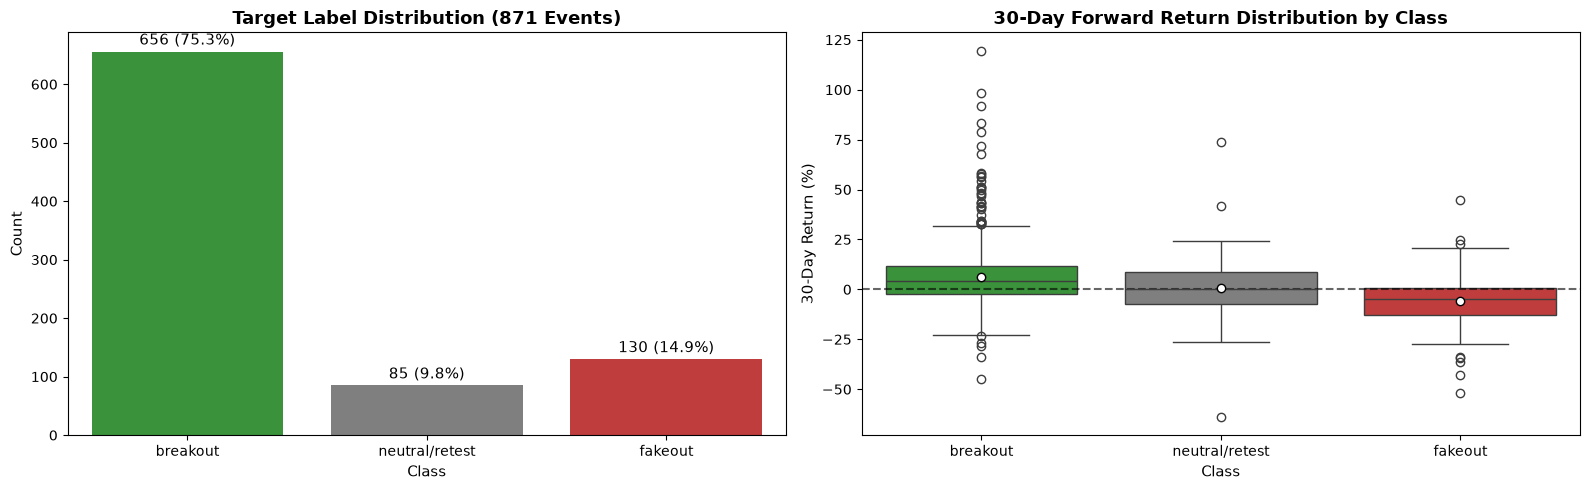

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Class Distribution
palette = {"breakout": "#2ca02c", "fakeout": "#d62728", "neutral/retest": "#7f7f7f"}
sns.countplot(data=df, x="Label", palette=palette, ax=axes[0])
axes[0].set_title("Target Label Distribution (871 Events)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Class", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)

for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                     textcoords='offset points')

# Plot 2: 30-Day Return Distribution by Label
sns.boxplot(data=df, x="Label", y="Return_30d_%", palette=palette, ax=axes[1], showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})
axes[1].axhline(0, color="black", linestyle="--", alpha=0.6)
axes[1].set_title("30-Day Forward Return Distribution by Class", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Class", fontsize=11)
axes[1].set_ylabel("30-Day Return (%)", fontsize=11)

plt.tight_layout()
plt.show()


## 8. Feature Engineering & Dataset Preparation for Machine Learning

### 8.1 Formal Definition of Feature Set $X$ (Strictly Day 0 and Prior)
To avoid any data leakage, we separate our columns into:
1. **Feature Matrix ($X$)**: 17 engineered indicators calculated **at or strictly before** the breakout day ($t \le i$).
2. **Target Vector ($y$)**: Ground-truth label (`breakout`, `fakeout`, `neutral/retest`).
3. **Quarantined Future Trackers**: 8 forward-looking columns (`Return_5d_%`, `Return_30d_%`, `Max_Gain_30d_%`, etc.) strictly **excluded** from $X$ and reserved solely for financial backtesting and performance evaluation.


In [ ]:
# 1. Feature Set X (Strictly Day 0 and Prior - NO LEAKAGE)
FEATURE_COLS = [
    # Price & Breakout Dynamics
    "Resistance_Distance_%",
    "Close_Position",
    "Daily_Range_%",
    "Range_Ratio",
    
    # Volume Dynamics
    "Volume_Ratio",
    "Volume_Surge_10",
    
    # Momentum & Run-up
    "Momentum_5d_%",
    "Momentum_10d_%",
    "Momentum_20d_%",
    
    # Trend & Moving Averages
    "MA_Ratio",
    "Distance_MA10_%",
    "Distance_MA30_%",
    
    # Volatility & Base Structure
    "ATR_Pct",
    "Volatility_10d",
    "Price_Range_10d_%",
    "Resistance_Tests_30d",
    "RSI_14"
]

TARGET_COL = "Label"

# Quarantined Future Columns (STRICTLY FORBIDDEN AS FEATURES)
FUTURE_COLS = [
    "Days_Above_5d",
    "Avg_Close_5d",
    "Return_5d_%",
    "Return_30d_%",
    "Max_Gain_30d_%",
    "Max_Drawdown_30d_%",
    "Pct_Days_Above_30d",
    "Continued_Up_30d"
]

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

print(f"Feature Matrix X Shape: {X.shape[0]:,} samples x {X.shape[1]} features")
print(f"Target Vector y Shape: {y.shape[0]:,} samples")
print(f"Zero Future Leakage Verified: {len(set(FEATURE_COLS).intersection(set(FUTURE_COLS)))} overlapping columns!")

Feature Matrix X Shape: 871 samples x 17 features
Target Vector y Shape: 871 samples
Zero Future Leakage Verified: 0 overlapping columns!


### 8.2 Feature Profiles by Target Label
Inspect the average values of each engineered feature across the three outcome classes (`breakout`, `fakeout`, `neutral/retest`). This reveals key predictive differentiators before any modeling.


In [ ]:
feature_means = df.groupby(TARGET_COL)[FEATURE_COLS].mean().round(2).T
feature_means

Label,breakout,fakeout,neutral/retest
Resistance_Distance_%,3.33,2.31,2.48
Close_Position,0.88,0.88,0.89
Daily_Range_%,4.26,4.26,4.54
Range_Ratio,1.73,1.54,1.46
Volume_Ratio,2.02,1.82,1.68
Volume_Surge_10,1.99,1.80,1.61
Momentum_5d_%,9.59,10.29,9.75
Momentum_10d_%,12.27,13.61,14.06
Momentum_20d_%,15.92,17.19,19.32
MA_Ratio,1.04,1.04,1.05


### 8.3 Feature Correlation Heatmap
Analyze pairwise multicollinearity and feature interactions across the 17 indicators.


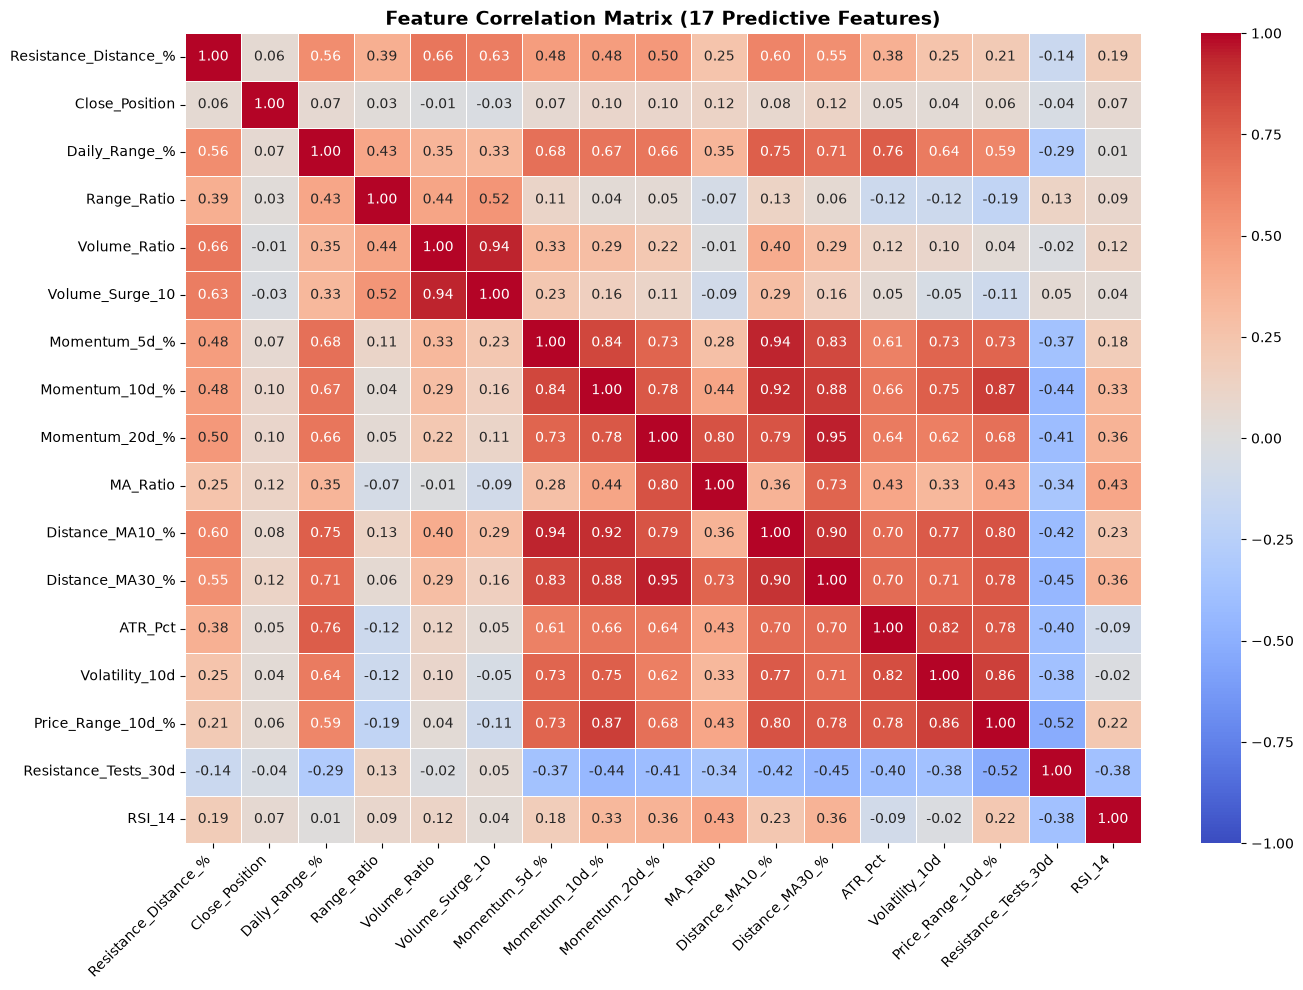

In [ ]:
plt.figure(figsize=(14, 10))
corr_matrix = X.corr().round(2)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix (17 Predictive Features)", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 8.4 Chronological Train / Test Split (Time-Series Aware)
In financial time series, random shuffling introduces temporal data leakage. We perform an **80/20 Chronological Split** based on historical dates:
- **Training Set (80%)**: Historical data from earliest date up to cutoff date.
- **Testing Set (20%)**: Out-of-Sample unseen future market data.


In [11]:
# Sort chronologically
df_sorted = df.sort_values("Date").reset_index(drop=True)

split_idx = int(len(df_sorted) * 0.80)
cutoff_date = df_sorted.loc[split_idx, "Date"]

train_df = df_sorted.iloc[:split_idx].copy()
test_df = df_sorted.iloc[split_idx:].copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]

X_test = test_df[FEATURE_COLS]
y_test = test_df[TARGET_COL]

print("=== CHRONOLOGICAL SPLIT SUMMARY ===")
print(f"Cutoff Date: {cutoff_date.strftime('%Y-%m-%d')}")
print(f"Train Set: {X_train.shape[0]} samples ({train_df['Date'].min().strftime('%Y-%m-%d')} to {train_df['Date'].max().strftime('%Y-%m-%d')})")
print(f"Test Set:  {X_test.shape[0]} samples ({test_df['Date'].min().strftime('%Y-%m-%d')} to {test_df['Date'].max().strftime('%Y-%m-%d')})")

print("\n=== TRAIN CLASS DISTRIBUTION ===")
print(y_train.value_counts(normalize=True).round(3) * 100)

print("\n=== TEST CLASS DISTRIBUTION ===")
print(y_test.value_counts(normalize=True).round(3) * 100)


=== CHRONOLOGICAL SPLIT SUMMARY ===
Cutoff Date: 2021-05-07
Train Set: 696 samples (2000-02-18 to 2021-05-05)
Test Set:  175 samples (2021-05-07 to 2026-06-26)

=== TRAIN CLASS DISTRIBUTION ===
Label
breakout          74.7
fakeout           15.1
neutral/retest    10.2
Name: proportion, dtype: float64

=== TEST CLASS DISTRIBUTION ===
Label
breakout          77.7
fakeout           14.3
neutral/retest     8.0
Name: proportion, dtype: float64
